In [1]:
import os
import torch
import timm
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from google.colab import drive

# 1. Monta Drive
drive.mount('/content/drive')

# Setup percorso
PROJECT_ROOT = '/content/drive/MyDrive/DeepLearning'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data/processed/images/train')
os.chdir(PROJECT_ROOT)

# Definiamo i 4 modelli che vogliamo testare
# Come indicato in letteratura, ViT, CLIP, DETR e ResNet sono le architetture chiave [cite: 564]
encoder_configs = {
    'vit': 'vit_large_patch32_384',
    'resnet': 'resnet50',
    'clip': 'resnet101', # Placeholder per testare una CNN robusta in stile CLIP
}

Mounted at /content/drive


In [2]:
import time

def benchmark_encoder(encoder_name, model_name, sample_input):
    try:
        model = timm.create_model(model_name, pretrained=True)
        model.eval()

        start_time = time.time()
        with torch.no_grad():
            # I Transformer (vit, swin) hanno spesso forward_features
            if hasattr(model, 'forward_features'):
                features = model.forward_features(sample_input)
            else:
                features = model(sample_input)
        end_time = time.time()

        return {
            "encoder": encoder_name,
            "latency": end_time - start_time,
            "feature_shape": tuple(features.shape)
        }
    except Exception as e:
        return {"encoder": encoder_name, "error": str(e)}


# Creiamo un tensore "dummy" per simulare un'immagine di input (Batch, Canali, Altezza, Larghezza)
# Usiamo 384x384 perché è la risoluzione di target che abbiamo impostato
sample_input = torch.randn(1, 3, 384, 384)

# Assicuriamoci che il tensore sia sul dispositivo corretto (GPU se disponibile)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sample_input = sample_input.to(device)

print(f"Tensor di test creato con shape: {sample_input.shape}")
# Ora esegui il loop
results = []
for name, model_name in encoder_configs.items():
    print(f"Testing {name}...")
    res = benchmark_encoder(name, model_name, sample_input)
    results.append(res)

print("\nRisultati Benchmark:")
for r in results:
    print(r)

Tensor di test creato con shape: torch.Size([1, 3, 384, 384])
Testing vit...


model.safetensors:   0%|          | 0.00/1.23G [00:00<?, ?B/s]

Testing resnet...


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Testing clip...


model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]


Risultati Benchmark:
{'encoder': 'vit', 'latency': 1.865096092224121, 'feature_shape': (1, 145, 1024)}
{'encoder': 'resnet', 'latency': 0.7982292175292969, 'feature_shape': (1, 2048, 12, 12)}
{'encoder': 'clip', 'latency': 0.8192100524902344, 'feature_shape': (1, 2048, 12, 12)}


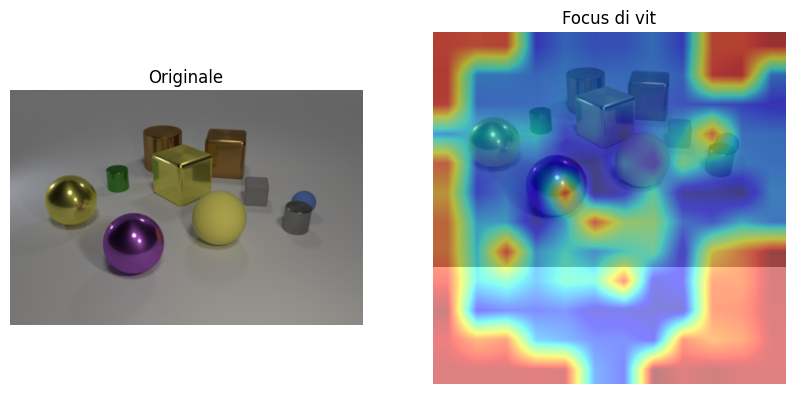

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import timm
import os

# Assicurati di aver definito encoder_configs (come fatto nel blocco precedente)
# encoder_configs = {'vit': 'vit_large_patch32_384', 'resnet': 'resnet50', 'clip': 'resnet101'}
class ResizeAndPad:
    def __init__(self, size):
        self.size = size

    def __call__(self, img):
        # 1. Ridimensiona mantenendo il rapporto d'aspetto (thumbnail non deforma)
        img.thumbnail((self.size, self.size))

        # 2. Crea un canvas nero quadrato
        new_img = Image.new("RGB", (self.size, self.size), (0, 0, 0))

        # 3. Incolla l'immagine originale al centro
        left = (self.size - img.width) // 2
        top = (self.size - img.height) // 2
        new_img.paste(img, (left, top))
        return new_img

def get_activation_map(model, input_tensor, encoder_type):
    activation = {}
    def get_activation(name):
        def hook(model, input, output):
            activation[name] = output.detach()
        return hook

    # Registra l'hook
    if encoder_type == 'vit':
        handle = model.blocks[-1].norm1.register_forward_hook(get_activation('feat'))
    else:
        handle = model.layer4.register_forward_hook(get_activation('feat'))

    model.eval()
    with torch.no_grad():
        model(input_tensor)
    handle.remove()

    feat = activation['feat']

    # Processamento mappa
    if encoder_type == 'vit':
        map_size = int(feat.shape[1]**0.5)
        feat_map = feat[:, 1:, :].mean(dim=-1).reshape(1, map_size, map_size)
    else:
        feat_map = feat.mean(dim=1)

    feat_map = F.interpolate(feat_map.unsqueeze(1), size=(384, 384), mode='bilinear').squeeze()
    return feat_map.cpu().numpy()

def visualize_encoder_decision(encoder_type, image_path):
    # 1. Caricamento immagine
    img = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
    ResizeAndPad(384), # Usa la nostra nuova classe
    transforms.ToTensor()
])
    input_tensor = transform(img).unsqueeze(0)

    # 2. Caricamento modello
    model = timm.create_model(encoder_configs[encoder_type], pretrained=True)

    # 3. Estrazione heatmap
    heatmap = get_activation_map(model, input_tensor, encoder_type)

    # 4. Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Originale")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title(f"Focus di {encoder_type}")
    plt.axis('off')
    plt.show()

# --- ESEMPIO DI UTILIZZO ---
# Modifica questo percorso con uno dei file che hai nella cartella data/CLEVR_v1.0/images/val/
sample_image = os.path.join(DATA_DIR, 'CLEVR_train_046708.png')

# Prova per un encoder
visualize_encoder_decision('vit', sample_image)

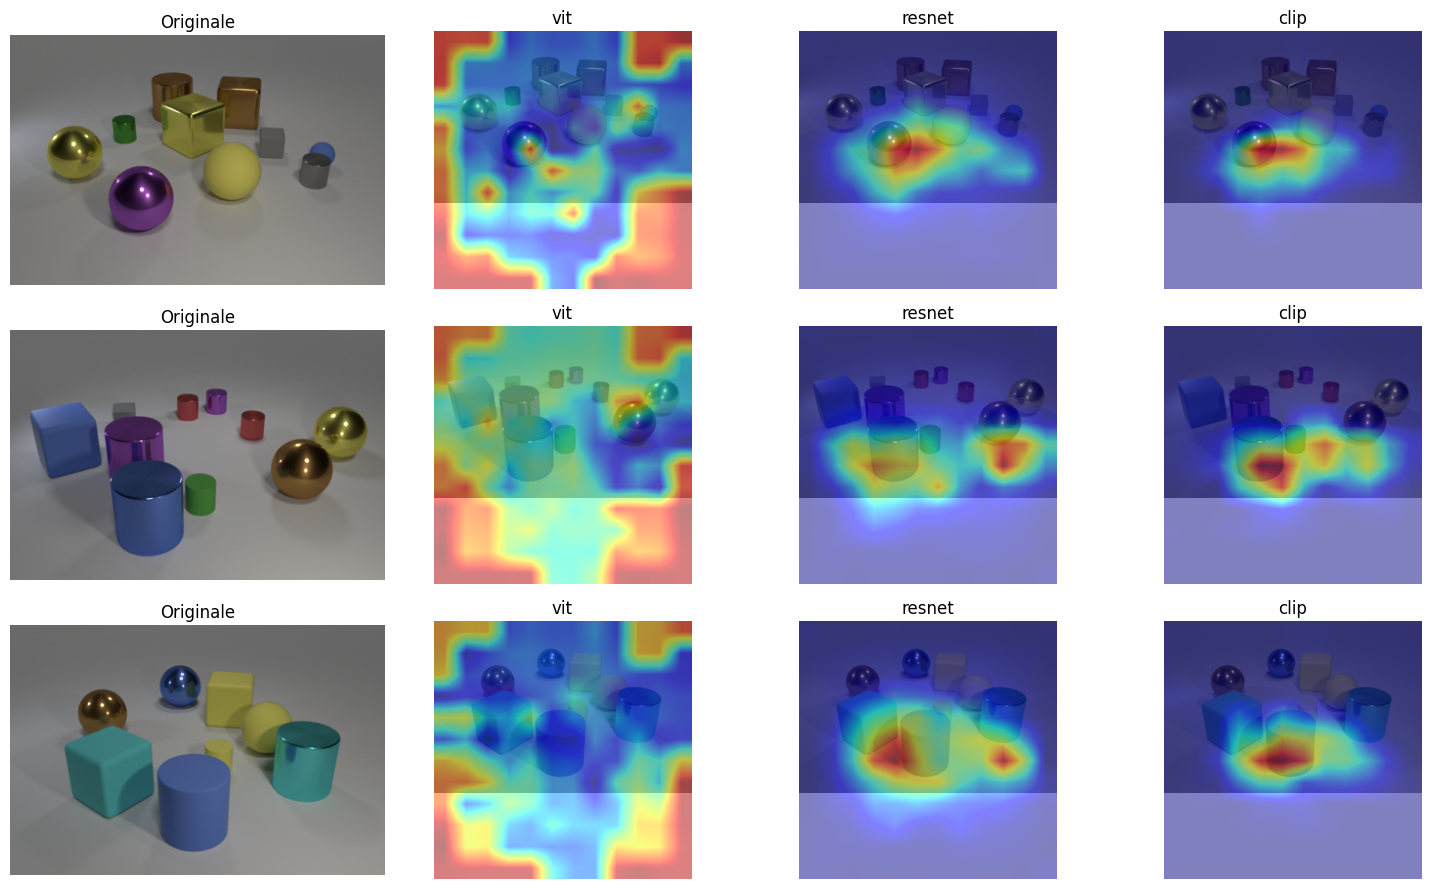

In [4]:
def run_comparison_batch(encoder_names, image_paths):
    """
    Esegue il confronto incrociato tra N modelli e M immagini.
    """
    n_models = len(encoder_names)
    n_images = len(image_paths)

    # Creiamo una griglia (righe = immagini, colonne = modelli)
    fig, axes = plt.subplots(n_images, n_models + 1, figsize=(15, 3 * n_images))

    for i, img_path in enumerate(image_paths):
        # Carica immagine
        img = Image.open(img_path).convert('RGB')
        transform = transforms.Compose([
    ResizeAndPad(384), # Usa la nostra nuova classe
    transforms.ToTensor()
])
        input_tensor = transform(img).unsqueeze(0)

        # Plot colonna 1: Immagine Originale
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Originale")
        axes[i, 0].axis('off')

        # Loop sui modelli
        for j, enc_type in enumerate(encoder_names):
            model = timm.create_model(encoder_configs[enc_type], pretrained=True)
            heatmap = get_activation_map(model, input_tensor, enc_type)

            axes[i, j+1].imshow(img)
            axes[i, j+1].imshow(heatmap, cmap='jet', alpha=0.5)
            axes[i, j+1].set_title(f"{enc_type}")
            axes[i, j+1].axis('off')

    plt.tight_layout()
    plt.show()

# --- Esecuzione ---
# Scegli 3 immagini dal tuo dataset
sample_images = [
    os.path.join(DATA_DIR, 'CLEVR_train_046708.png'),
    os.path.join(DATA_DIR, 'CLEVR_train_050337.png'),
    os.path.join(DATA_DIR, 'CLEVR_train_040602.png')
]

# Esegui il confronto (usando i 3 encoder validi)
run_comparison_batch(['vit', 'resnet', 'clip'], sample_images)

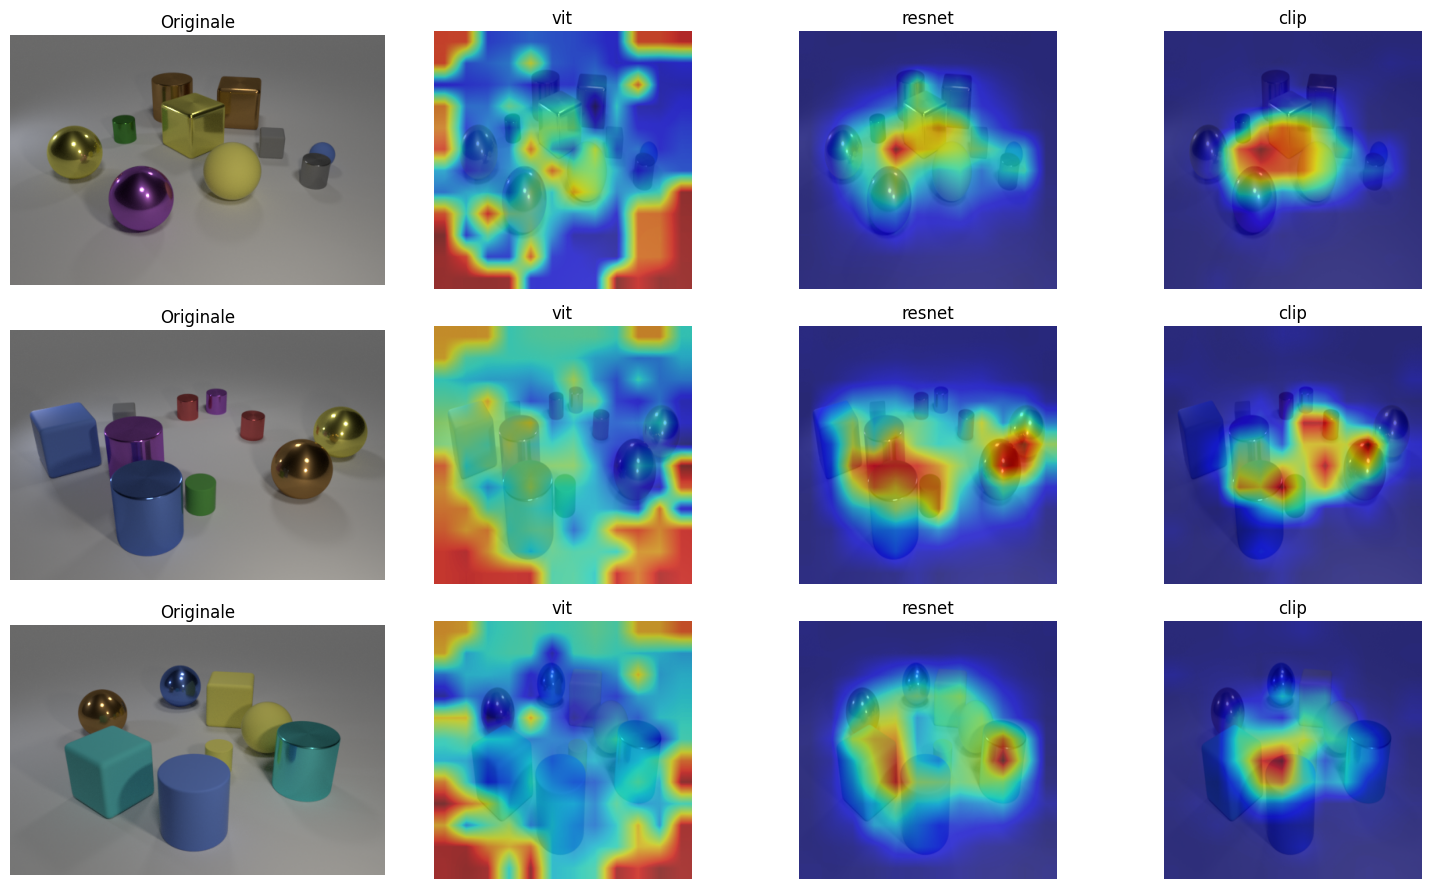

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

def visualize_encoder_decision_clean(encoder_names, image_paths):
    n_models = len(encoder_names)
    n_images = len(image_paths)

    # Setup della griglia
    fig, axes = plt.subplots(n_images, n_models + 1, figsize=(15, 3 * n_images))

    # Trasformazione standard (il resize a 384x384 è lo standard richiesto dagli encoder)
    transform = transforms.Compose([transforms.Resize((384, 384)), transforms.ToTensor()])

    for i, img_path in enumerate(image_paths):
        img = Image.open(img_path).convert('RGB')
        input_tensor = transform(img).unsqueeze(0)

        # Plot colonna 1: Originale
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Originale")
        axes[i, 0].axis('off')

        for j, enc_type in enumerate(encoder_names):
            model = timm.create_model(encoder_configs[enc_type], pretrained=True).eval()
            heatmap = get_activation_map(model, input_tensor, enc_type)

            axes[i, j+1].imshow(img.resize((384, 384)))
            axes[i, j+1].imshow(heatmap, cmap='jet', alpha=0.6)
            axes[i, j+1].set_title(f"{enc_type}")
            axes[i, j+1].axis('off')

    plt.tight_layout()
    plt.show()

# Esegui il test pulito
visualize_encoder_decision_clean(['vit', 'resnet', 'clip'], sample_images)